In [1]:
# Importing necessary libraries 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans , AgglomerativeClustering , DBSCAN
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings("ignore")

In [2]:
#Loading the dataset
df = pd.read_excel("World_development_mesurement.xlsx")
df.head()

,Birth Rate,Business Tax Rate,CO2 Emissions,Country,Days to Start Business,Ease of Business,Energy Usage,GDP,Health Exp % GDP,Health Exp/Capita,...,Life Expectancy Male,Mobile Phone Usage,Number of Records,Population 0-14,Population 15-64,Population 65+,Population Total,Population Urban,Tourism Inbound,Tourism Outbound
0,0.020,NaN,87931.0,Algeria,NaN,NaN,26998.0,"$54,790,058,957",0.035,$60,...,67.0,0.0,1,0.342,0.619,0.039,31719449,0.599,"$102,000,000","$193,000,000"
1,0.050,NaN,9542.0,Angola,NaN,NaN,7499.0,"$9,129,594,819",0.034,$22,...,44.0,0.0,1,0.476,0.499,0.025,13924930,0.324,"$34,000,000","$146,000,000"
2,0.043,NaN,1617.0,Benin,NaN,NaN,1983.0,"$2,359,122,303",0.043,$15,...,53.0,0.0,1,0.454,0.517,0.029,6949366,0.383,"$77,000,000","$50,000,000"
3,0.027,NaN,4276.0,Botswana,NaN,NaN,1836.0,"$5,788,311,645",0.047,$152,...,49.0,0.1,1,0.383,0.587,0.029,1755375,0.532,"$227,000,000","$209,000,000"
4,0.046,NaN,1041.0,Burkina Faso,NaN,NaN,NaN,"$2,610,959,139",0.051,$12,...,49.0,0.0,1,0.468,0.505,0.028,11607944,0.178,"$23,000,000","$30,000,000"


In [3]:
# Checking number of rows and columns 
df.shape

(2704, 25)

In [4]:
# Getting detailed information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2704 entries, 0 to 2703
Data columns (total 25 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Birth Rate              2585 non-null   float64
 1   Business Tax Rate       1423 non-null   object 
 2   CO2 Emissions           2125 non-null   float64
 3   Country                 2704 non-null   object 
 4   Days to Start Business  1718 non-null   float64
 5   Ease of Business        185 non-null    float64
 6   Energy Usage            1785 non-null   float64
 7   GDP                     2494 non-null   object 
 8   Health Exp % GDP        2395 non-null   float64
 9   Health Exp/Capita       2395 non-null   object 
 10  Hours to do Tax         1416 non-null   float64
 11  Infant Mortality Rate   2444 non-null   float64
 12  Internet Usage          2531 non-null   float64
 13  Lending Interest        1880 non-null   float64
 14  Life Expectancy Female  2568 non-null   

In [5]:
df['Country'].nunique()

208

The dataset has data for 208 countries.

In [6]:
#Checking for duplicates
df.duplicated().sum()

np.int64(0)

In [7]:
# Checking missing values in each column
df.isnull().sum()

Birth Rate                 119
Business Tax Rate         1281
CO2 Emissions              579
Country                      0
Days to Start Business     986
Ease of Business          2519
Energy Usage               919
GDP                        210
Health Exp % GDP           309
Health Exp/Capita          309
Hours to do Tax           1288
Infant Mortality Rate      260
Internet Usage             173
Lending Interest           824
Life Expectancy Female     136
Life Expectancy Male       136
Mobile Phone Usage         167
Number of Records            0
Population 0-14            220
Population 15-64           220
Population 65+             220
Population Total             0
Population Urban            26
Tourism Inbound            368
Tourism Outbound           471
dtype: int64

In [8]:
# Checking percentage of missing values column wise
missing_percent = (df.isnull().sum()/len(df))*100
missing_percent

Birth Rate                 4.400888
Business Tax Rate         47.374260
CO2 Emissions             21.412722
Country                    0.000000
Days to Start Business    36.464497
Ease of Business          93.158284
Energy Usage              33.986686
GDP                        7.766272
Health Exp % GDP          11.427515
Health Exp/Capita         11.427515
Hours to do Tax           47.633136
Infant Mortality Rate      9.615385
Internet Usage             6.397929
Lending Interest          30.473373
Life Expectancy Female     5.029586
Life Expectancy Male       5.029586
Mobile Phone Usage         6.176036
Number of Records          0.000000
Population 0-14            8.136095
Population 15-64           8.136095
Population 65+             8.136095
Population Total           0.000000
Population Urban           0.961538
Tourism Inbound           13.609467
Tourism Outbound          17.418639
dtype: float64

In [9]:
# Drop columns with more than 40% missing values
cols_to_drop = missing_percent[missing_percent > 40].index
print("Columns to be dropped:", list(cols_to_drop))

df = df.drop(columns=cols_to_drop)

Columns to be dropped: ['Business Tax Rate', 'Ease of Business', 'Hours to do Tax']


Columns with more than 40% missing values were dropped.

In [10]:
df = df.drop(columns=["Number of Records"])

Number of Records does not provide meaningful information for analysis.So , dropped this column also.

In [11]:
# Checking dataset structure after dropping columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2704 entries, 0 to 2703
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Birth Rate              2585 non-null   float64
 1   CO2 Emissions           2125 non-null   float64
 2   Country                 2704 non-null   object 
 3   Days to Start Business  1718 non-null   float64
 4   Energy Usage            1785 non-null   float64
 5   GDP                     2494 non-null   object 
 6   Health Exp % GDP        2395 non-null   float64
 7   Health Exp/Capita       2395 non-null   object 
 8   Infant Mortality Rate   2444 non-null   float64
 9   Internet Usage          2531 non-null   float64
 10  Lending Interest        1880 non-null   float64
 11  Life Expectancy Female  2568 non-null   float64
 12  Life Expectancy Male    2568 non-null   float64
 13  Mobile Phone Usage      2537 non-null   float64
 14  Population 0-14         2484 non-null   

In [12]:
# Removing $, commas, % from relevant columns and converting them to numeric
df['GDP'] = df['GDP'].replace(r'[\$,]', '', regex=True).astype(float)
df['Tourism Inbound'] = df['Tourism Inbound'].replace(r'[\$,]', '', regex=True).astype(float)
df['Tourism Outbound'] = df['Tourism Outbound'].replace(r'[\$,]', '', regex=True).astype(float)
df['Health Exp/Capita'] = df['Health Exp/Capita'].replace(r'[\$,]', '', regex=True).astype(float)

In [13]:
# Verifying data types after cleaning. 
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2704 entries, 0 to 2703
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Birth Rate              2585 non-null   float64
 1   CO2 Emissions           2125 non-null   float64
 2   Country                 2704 non-null   object 
 3   Days to Start Business  1718 non-null   float64
 4   Energy Usage            1785 non-null   float64
 5   GDP                     2494 non-null   float64
 6   Health Exp % GDP        2395 non-null   float64
 7   Health Exp/Capita       2395 non-null   float64
 8   Infant Mortality Rate   2444 non-null   float64
 9   Internet Usage          2531 non-null   float64
 10  Lending Interest        1880 non-null   float64
 11  Life Expectancy Female  2568 non-null   float64
 12  Life Expectancy Male    2568 non-null   float64
 13  Mobile Phone Usage      2537 non-null   float64
 14  Population 0-14         2484 non-null   

All columns are numeric except 'Country', which is categorical.

In [14]:
# Filling missing values in numeric columns
df.fillna(df.median(numeric_only=True), inplace=True)

In [15]:
# Checking if any missing values remain after filling them
df.isnull().sum()

Birth Rate                0
CO2 Emissions             0
Country                   0
Days to Start Business    0
Energy Usage              0
GDP                       0
Health Exp % GDP          0
Health Exp/Capita         0
Infant Mortality Rate     0
Internet Usage            0
Lending Interest          0
Life Expectancy Female    0
Life Expectancy Male      0
Mobile Phone Usage        0
Population 0-14           0
Population 15-64          0
Population 65+            0
Population Total          0
Population Urban          0
Tourism Inbound           0
Tourism Outbound          0
dtype: int64

This step confirms that all missing values have been successfully handled.

In [16]:
# Aggregating data at country level
df_country = df.groupby("Country").mean()
df_country.shape

(208, 20)

- The dataset contains multiple records per country.
- So, the data was aggregated using the mean to create a single record for each country.

In [17]:
df_country.head()

,Birth Rate,CO2 Emissions,Days to Start Business,Energy Usage,GDP,Health Exp % GDP,Health Exp/Capita,Infant Mortality Rate,Internet Usage,Lending Interest,Life Expectancy Female,Life Expectancy Male,Mobile Phone Usage,Population 0-14,Population 15-64,Population 65+,Population Total,Population Urban,Tourism Inbound,Tourism Outbound
Country,,,,,,,,,,,,,,,,,,,,
Afghanistan,0.043154,3322.384615,13.615385,14338.000000,1.013132e+10,0.087154,55.615385,0.082769,0.023077,0.141385,58.769231,56.384615,0.292308,0.490308,0.488769,0.020769,2.539926e+07,0.232923,4.644615e+08,3.123077e+08
Albania,0.014692,4613.923077,23.692308,2971.769231,8.895522e+09,0.061462,168.846154,0.017769,0.192308,0.142385,79.230769,73.000000,0.561538,0.258385,0.653692,0.087923,2.956845e+06,0.478538,1.165231e+09,1.007077e+09
Algeria,0.022077,88328.615385,25.230769,32526.461538,1.190391e+11,0.038462,133.846154,0.027769,0.069231,0.083231,71.615385,68.384615,0.492308,0.292692,0.663077,0.044231,3.476067e+07,0.645154,2.752308e+08,4.513077e+08
American Samoa,0.020077,8529.000000,26.000000,14338.000000,1.507975e+10,0.061000,193.000000,0.020000,0.100000,0.120000,75.000000,69.000000,0.307692,0.299500,0.642500,0.052000,5.752538e+04,0.880000,6.885000e+08,4.560000e+08
Andorra,0.011308,1767.076923,26.000000,14338.000000,6.210341e+09,0.063231,2394.461538,0.003000,0.484615,0.120000,75.000000,69.000000,0.700000,0.299500,0.642500,0.052000,7.668408e+04,0.897462,6.885000e+08,4.560000e+08


In [18]:
df_country.info()

<class 'pandas.core.frame.DataFrame'>
Index: 208 entries, Afghanistan to Zimbabwe
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Birth Rate              208 non-null    float64
 1   CO2 Emissions           208 non-null    float64
 2   Days to Start Business  208 non-null    float64
 3   Energy Usage            208 non-null    float64
 4   GDP                     208 non-null    float64
 5   Health Exp % GDP        208 non-null    float64
 6   Health Exp/Capita       208 non-null    float64
 7   Infant Mortality Rate   208 non-null    float64
 8   Internet Usage          208 non-null    float64
 9   Lending Interest        208 non-null    float64
 10  Life Expectancy Female  208 non-null    float64
 11  Life Expectancy Male    208 non-null    float64
 12  Mobile Phone Usage      208 non-null    float64
 13  Population 0-14         208 non-null    float64
 14  Population 15-64        208 non-

In [19]:
df_country.describe().T

,count,mean,std,min,25%,50%,75%,max
Birth Rate,208.0,2.259541e-02,1.101922e-02,8.384615e-03,1.300000e-02,1.984615e-02,2.900000e-02,5.115385e-02
CO2 Emissions,208.0,1.136616e+05,4.942833e+05,1.352385e+03,2.740750e+03,8.529000e+03,4.683056e+04,4.802171e+06
Days to Start Business,208.0,3.489460e+01,3.523673e+01,8.307692e+00,2.151923e+01,2.600000e+01,3.701923e+01,4.370769e+02
Energy Usage,208.0,5.585961e+04,2.073575e+05,1.782923e+03,9.359019e+03,1.433800e+04,2.467617e+04,2.250944e+06
GDP,208.0,2.445336e+11,1.062132e+12,1.145310e+08,5.105775e+09,1.507975e+10,1.005770e+11,1.330715e+13
Health Exp % GDP,208.0,6.380732e-02,2.337100e-02,2.061538e-02,4.917308e-02,6.100000e-02,7.625000e-02,1.803846e-01
Health Exp/Capita,208.0,7.318724e+02,1.334625e+03,8.538462e+00,6.767308e+01,1.930000e+02,5.610577e+02,6.967385e+03
Infant Mortality Rate,208.0,3.158099e-02,2.821184e-02,2.307692e-03,1.034615e-02,2.000000e-02,4.963462e-02,1.251538e-01
Internet Usage,208.0,2.308062e-01,2.206029e-01,0.000000e+00,4.615385e-02,1.615385e-01,3.730769e-01,8.153846e-01
Lending Interest,208.0,1.395388e-01,9.220991e-02,1.769231e-02,1.000192e-01,1.200000e-01,1.525385e-01,1.017769e+00


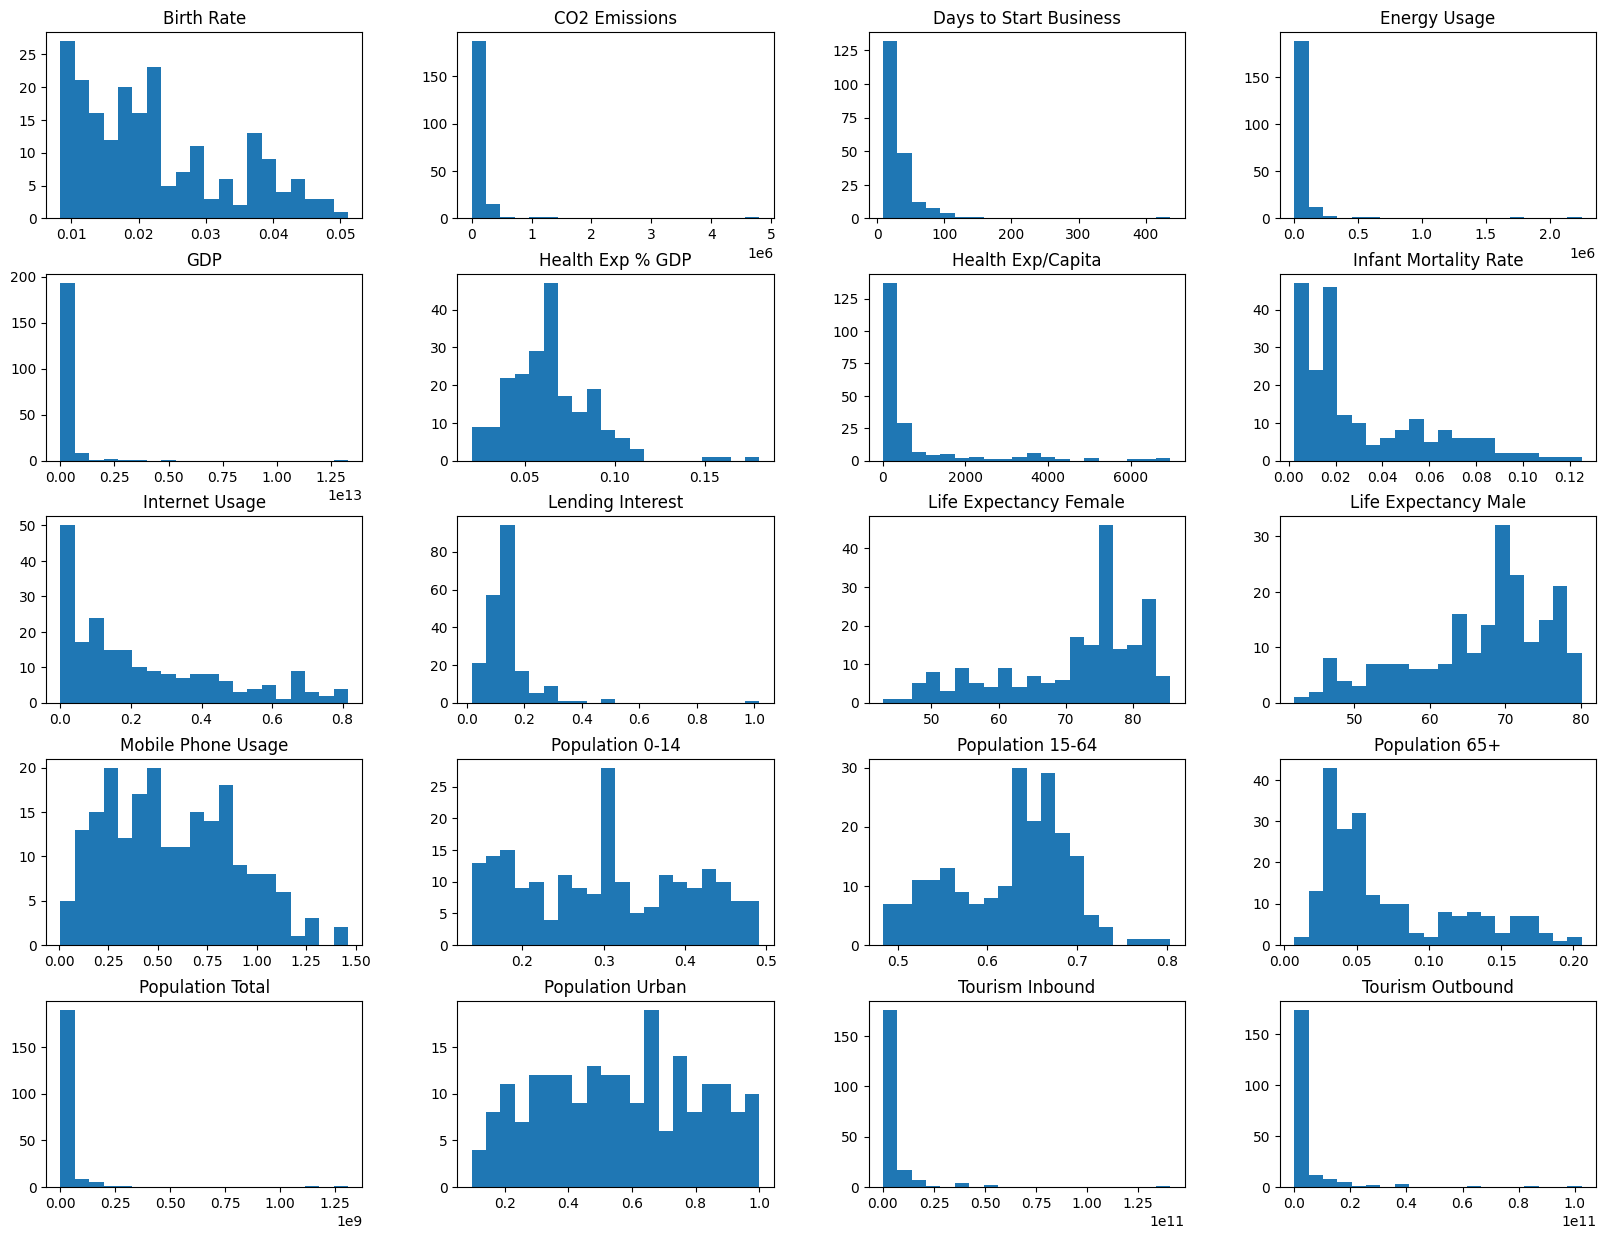

In [20]:
# Plotting histograms for all numeric variables to understand their distribution
df_country.hist(bins=20, figsize=(20,15), grid=False)
plt.show()

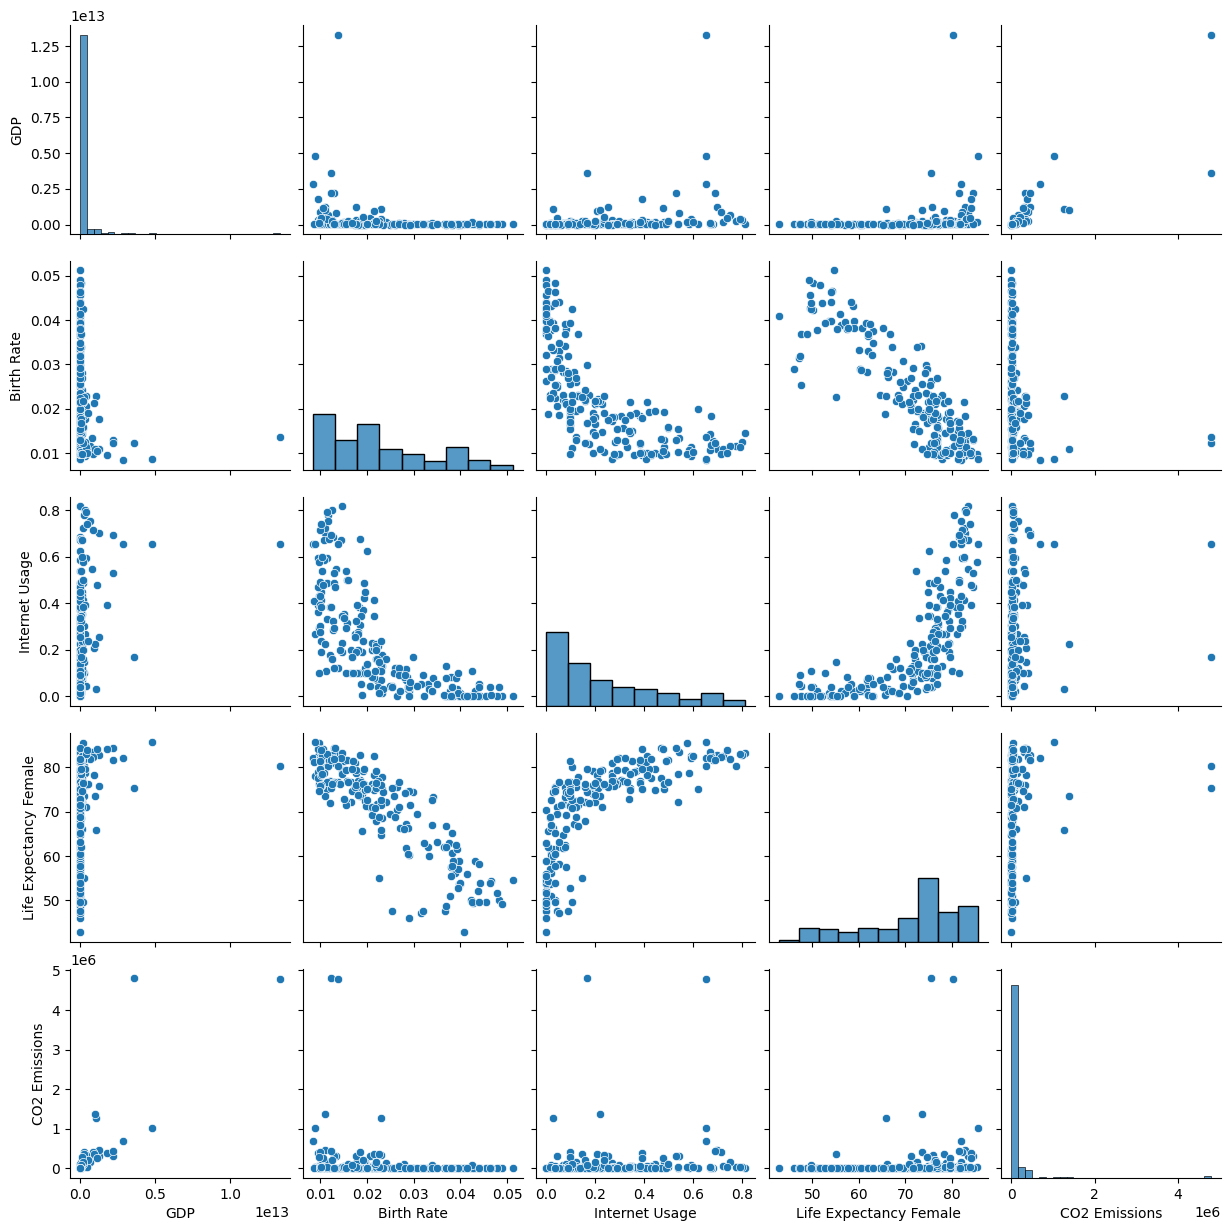

In [21]:
# Pairplot to visualize relationships between selected development indicators
sns.pairplot(df_country[['GDP','Birth Rate','Internet Usage','Life Expectancy Female','CO2 Emissions']])
plt.show()

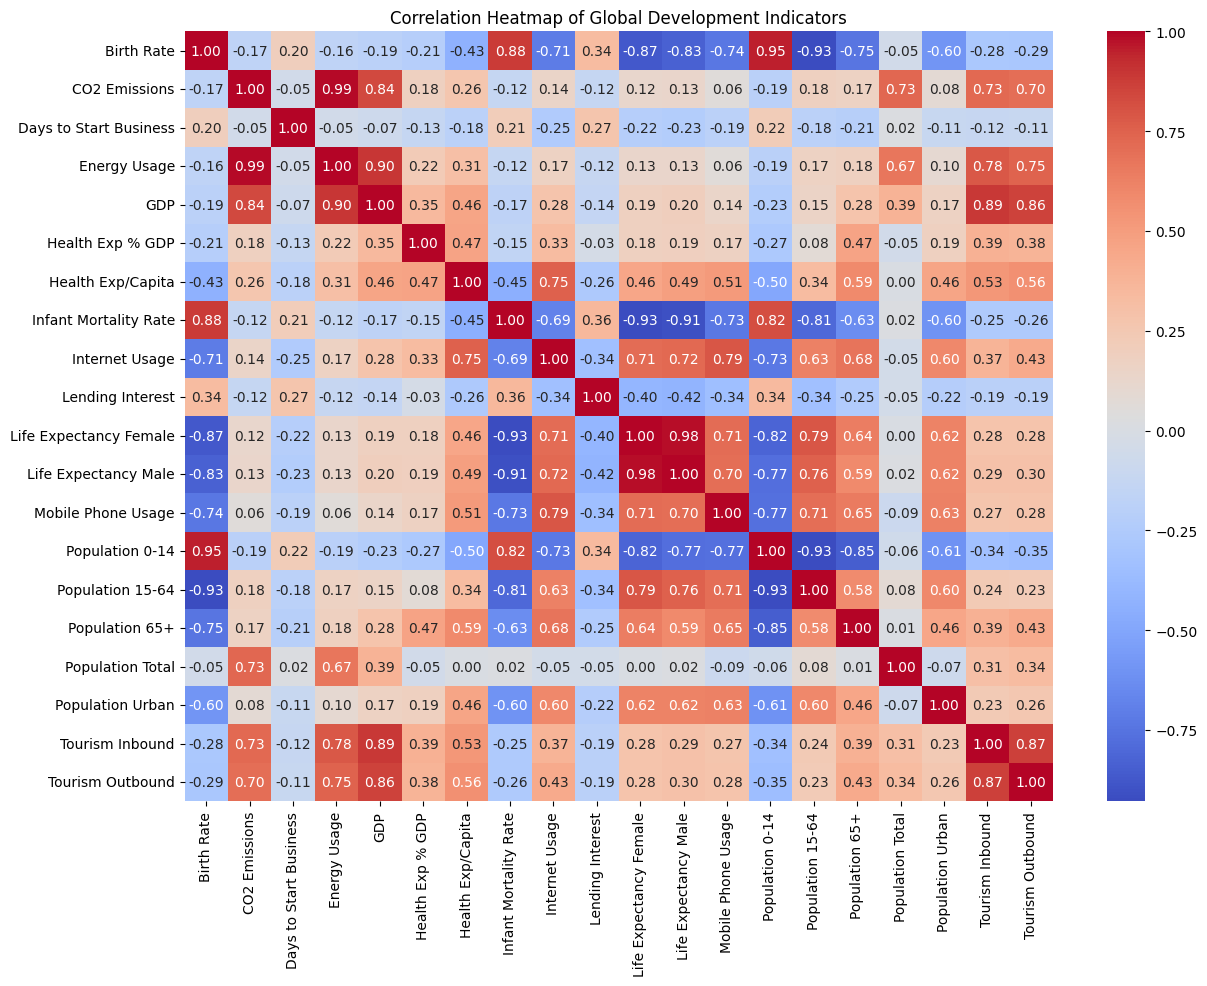

In [22]:
# Showing Correlation heatmap 
plt.figure(figsize=(14,10))
sns.heatmap(df_country.corr(), cmap="coolwarm", annot=True, fmt= ".2f")
plt.title("Correlation Heatmap of Global Development Indicators")
plt.show()

- The heatmap shows strong positive correlations between indicators like GDP, Energy Usage and CO₂ Emissions, indicating that more developed economies tend to consume more energy.
- It also shows strong negative correlations between Birth Rate and Life Expectancy, suggesting that countries with higher life expectancy generally have lower birth rates.

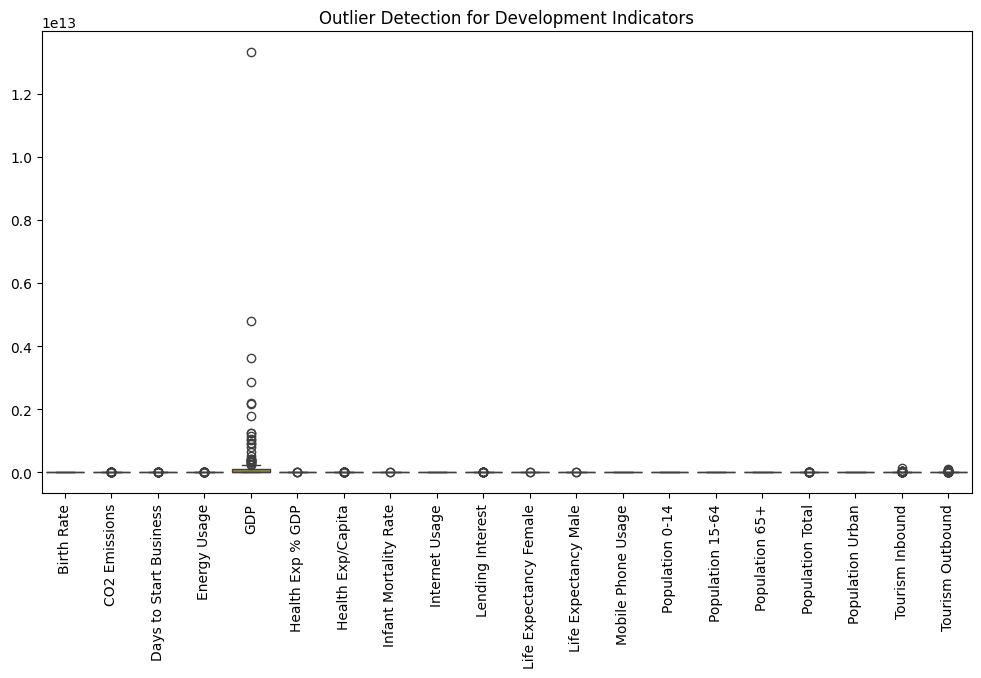

In [23]:
# Boxplot to detect outliers in development indicators
plt.figure(figsize=(12,6))
sns.boxplot(data=df_country)
plt.xticks(rotation=90)
plt.title("Outlier Detection for Development Indicators")
plt.show()

- The boxplot helps identify potential outliers in several development indicators.
- Some variables appear compressed due to differences in scale.

In [24]:
# Applying log transformation to reduce skewness in the data
df_country = np.log1p(df_country)

Log transformation is applied to reduce skewness and bring the data closer to a normal distribution, which helps improve clustering performance.

In [25]:
# Capping outliers using IQR method to reduce the impact of extreme values
for col in df_country.columns:
    Q1 = df_country[col].quantile(0.25)
    Q3 = df_country[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    df_country[col] = np.clip(df_country[col], lower, upper)

Outliers are capped using the IQR method to limit extreme values without removing data points, which helps improve clustering performance.

In [26]:
# Standardizing the data using StandardScaler to bring all features to the same scale
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_country)
# Converting back to DataFrame (for readability)
df_scaled = pd.DataFrame(df_scaled, columns=df_country.columns, index=df_country.index)
df_scaled.head()

,Birth Rate,CO2 Emissions,Days to Start Business,Energy Usage,GDP,Health Exp % GDP,Health Exp/Capita,Infant Mortality Rate,Internet Usage,Lending Interest,Life Expectancy Female,Life Expectancy Male,Mobile Phone Usage,Population 0-14,Population 15-64,Population 65+,Population Total,Population Urban,Tourism Inbound,Tourism Outbound
Country,,,,,,,,,,,,,,,,,,,,
Afghanistan,1.863936,-0.750524,-1.475743,-0.046379,-0.312282,1.155623,-0.869562,1.835686,-1.008785,0.261363,-1.212314,-1.120049,-0.860250,1.773888,-2.136987,-1.099034,0.800436,-1.413529,-0.338814,-0.367476
Albania,-0.719067,-0.571896,-0.368065,-1.628512,-0.370981,-0.070138,-0.165655,-0.489187,-0.100903,0.281517,0.747330,0.709280,0.065088,-0.408411,0.450870,0.367445,-0.139393,-0.270718,0.177429,0.275431
Algeria,-0.041987,1.034110,-0.240401,0.777223,0.799501,-1.192886,-0.313508,-0.122012,-0.747084,-0.942166,0.083522,0.245993,-0.156650,-0.061390,0.590260,-0.576004,0.937554,0.401004,-0.632503,-0.165316
American Samoa,-0.224879,-0.237671,-0.179350,-0.046379,-0.132812,-0.092428,-0.080461,-0.406967,-0.578819,-0.173923,0.386748,0.309516,-0.802383,0.006374,0.283592,-0.405391,-1.861046,1.240424,-0.117882,-0.159636
Andorra,-1.031043,-1.093889,-0.179350,-0.046379,-0.533127,0.015217,1.529980,-1.038129,1.199542,-0.173923,0.386748,0.309516,0.480501,0.006374,0.283592,-0.405391,-1.735423,1.298583,-0.117882,-0.159636


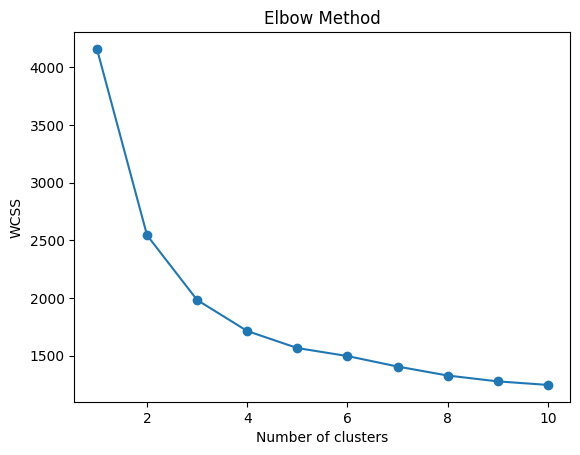

In [27]:
# Using Elbow Method to determine the optimal number of clusters for K-Means
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(df_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

From the Elbow Method, the optimal number of clusters is chosen as 4, as the curve starts to flatten after this point.

In [28]:
# Applying K-Means clustering with optimal number of clusters (k=4)
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(df_scaled)

df_country['KMeans_Cluster'] = kmeans_labels

In [29]:
# Evaluating K-Means clustering using Silhouette Score
kmeans_score = silhouette_score(df_scaled, kmeans_labels)
print("KMeans silhouette score:", kmeans_score)

KMeans silhouette score: 0.27283903747732696


In [30]:
# Applying Hierarchical (Agglomerative) clustering and evaluating using Silhouette Score
hc = AgglomerativeClustering(n_clusters=4)
hc_labels = hc.fit_predict(df_scaled)

df_country['HC_Cluster'] = hc_labels

hc_score = silhouette_score(df_scaled, hc_labels)
print("Hierarchical silhouette score:", hc_score)

Hierarchical silhouette score: 0.25007197375537543


The Silhouette Score for Hierarchical clustering is 0.25, which is slightly lower than K-Means, indicating weaker cluster separation.

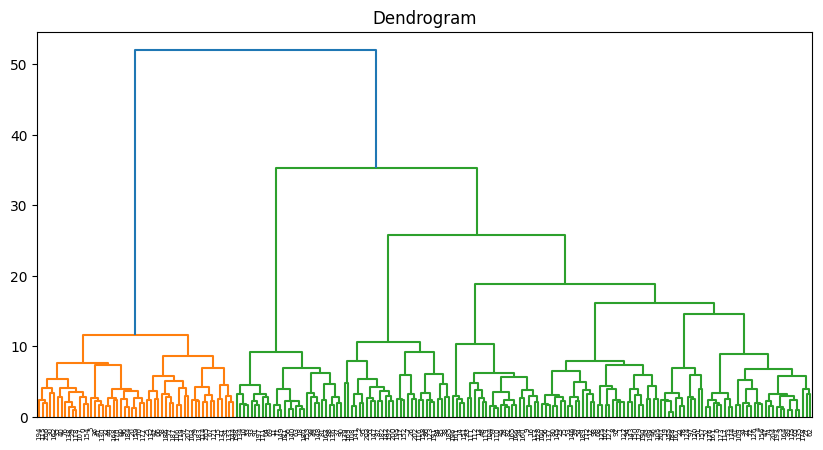

In [31]:
# Plotting dendrogram to visualize hierarchical clustering structure
linked = linkage(df_scaled, method='ward')

plt.figure(figsize=(10,5))
dendrogram(linked)
plt.title("Dendrogram")
plt.show()

- The dendrogram shows how clusters are formed by merging data points. 
- Based on the larger vertical distances, around 4 clusters can be identified.

In [32]:
# Applying DBSCAN clustering and evaluating using silhouette score
dbscan = DBSCAN(eps=1.5, min_samples=5)
dbscan_labels = dbscan.fit_predict(df_scaled)

df_country['DBSCAN_Cluster'] = dbscan_labels

# Remove noise points (-1)
mask = dbscan_labels != -1

if len(set(dbscan_labels[mask])) > 1:
    dbscan_score = silhouette_score(df_scaled[mask], dbscan_labels[mask])
    print("DBSCAN Silhouette Score:", dbscan_score)
else:
    print("DBSCAN could not form proper clusters")

DBSCAN could not form proper clusters


- DBSCAN could not form meaningful clusters for this dataset. 
- This is likely due to the high dimensional nature of the data and the lack of clear density-based separation between observations.

In [33]:
print("KMeans:", kmeans_score)
print("Hierarchical:", hc_score)

KMeans: 0.27283903747732696
Hierarchical: 0.25007197375537543


- Based on the Silhouette Scores, K-Means clustering performed better than Hierarchical clustering.
- K-Means achieved a higher score of 0.27 compared to 0.25 for Hierarchical clustering, indicating better-defined and more compact clusters.

In [34]:
# Applying PCA to reduce data to 2 dimensions for visualization
pca = PCA(n_components=2)
pca_data = pca.fit_transform(df_scaled)

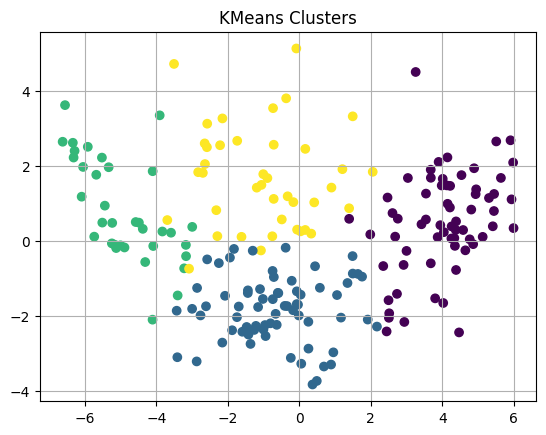

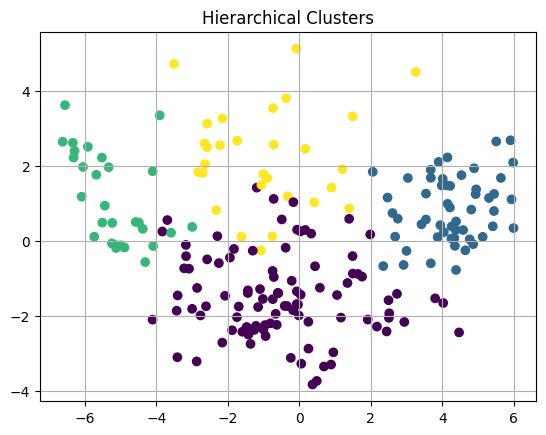

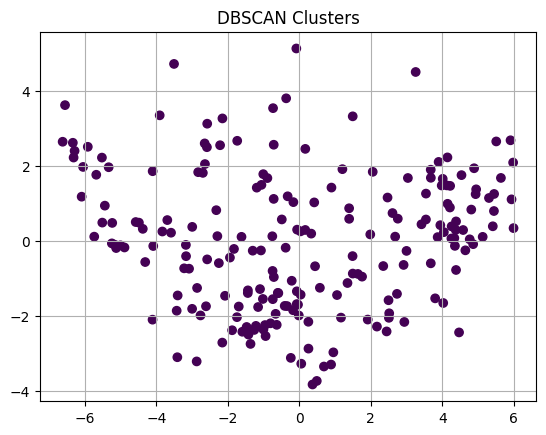

In [35]:
# Visualizing clusters formed by different algorithms using PCA-reduced data
plt.scatter(pca_data[:,0], pca_data[:,1], c=kmeans_labels)
plt.title("KMeans Clusters")
plt.grid(True)
plt.show()

plt.scatter(pca_data[:,0], pca_data[:,1], c=hc_labels)
plt.title("Hierarchical Clusters")
plt.grid(True)
plt.show()

plt.scatter(pca_data[:,0], pca_data[:,1], c=dbscan_labels)
plt.title("DBSCAN Clusters")
plt.grid(True)
plt.show()

- The above plots show the distribution of countries across different clusters formed using K-Means, Hierarchical, and DBSCAN algorithms after dimensionality reduction using PCA.
- K-Means and Hierarchical clustering show relatively clear cluster separation, while DBSCAN does not form well-defined clusters and classifies most points as noise.
- Based on visual observation, K-Means appears to form more distinct and compact clusters.

In [36]:
df_country['KMeans_Cluster'].value_counts()

KMeans_Cluster
1    69
0    64
3    40
2    35
Name: count, dtype: int64

- The K-Means algorithm grouped the countries into 4 clusters.
- Cluster 1 contains the highest number of countries (69), followed by Cluster 0 (64), Cluster 3 (40), and Cluster 2 (35).
- This indicates a reasonably balanced distribution of countries across clusters.

In [37]:
# Cluster Interpretation using Mean Values
df_country.groupby('KMeans_Cluster').mean().T

KMeans_Cluster,0,1,2,3
Birth Rate,0.035686,0.016837,0.011307,0.019855
CO2 Emissions,8.130410,8.524452,11.536228,11.530973
Days to Start Business,3.661576,3.266656,2.995277,3.465519
Energy Usage,9.180929,9.007575,10.548286,10.550387
GDP,22.214081,22.638888,26.597566,25.533428
Health Exp % GDP,0.057529,0.062408,0.081182,0.046545
Health Exp/Capita,3.883913,5.779242,7.616313,5.198146
Infant Mortality Rate,0.063733,0.016010,0.005489,0.024934
Internet Usage,0.034288,0.239581,0.436503,0.153021
Lending Interest,0.145063,0.118374,0.079694,0.122577


- The above table shows the mean values of different features for each cluster formed using K-Means.
- Cluster 0 represents countries with higher birth rates, higher infant mortality, and lower internet usage, indicating less developed countries.
- Cluster 1 represents countries with moderate values across most indicators, indicating developing countries.
- Cluster 2 shows higher GDP, higher internet and mobile usage, lower infant mortality, and higher life expectancy, representing developed countries.
- Cluster 3 represents countries with mixed characteristics, showing moderate development levels between developing and developed countries.
- Overall, the clustering groups countries based on their economic and social development levels.

In [38]:
cluster_names = {
    0: "Low Developed",
    1: "Moderately Developed",
    2: "Highly Developed",
    3: "Developing"
}

df_country['Cluster_Name'] = df_country['KMeans_Cluster'].map(cluster_names)

df_country[['KMeans_Cluster', 'Cluster_Name']].head()

,KMeans_Cluster,Cluster_Name
Country,,
Afghanistan,0,Low Developed
Albania,1,Moderately Developed
Algeria,3,Developing
American Samoa,1,Moderately Developed
Andorra,1,Moderately Developed


- We mapped these clusters to meaningful names based on their characteristics.
- Cluster numbers don’t have meaning by default, so we analyzed the cluster statistics and assigned names to make the results more interpretable.

In [39]:
# Print countries per cluster to confirm
for i in range(4):
    print(f"\n=== Cluster {i} ===")
    countries = df_country[df_country['KMeans_Cluster'] == i].index.tolist()
    print(countries)


=== Cluster 0 ===
['Afghanistan', 'Angola', 'Benin', 'Bhutan', 'Bolivia', 'Botswana', 'Burkina Faso', 'Burundi', 'Cambodia', 'Cameroon', 'Central African Republic', 'Chad', 'Comoros', 'Congo, Dem. Rep.', 'Congo, Rep.', "Cote d'Ivoire", 'Djibouti', 'Equatorial Guinea', 'Eritrea', 'Ethiopia', 'Gabon', 'Gambia, The', 'Ghana', 'Guatemala', 'Guinea', 'Guinea-Bissau', 'Guyana', 'Haiti', 'Kenya', 'Kiribati', 'Lao PDR', 'Lesotho', 'Liberia', 'Madagascar', 'Malawi', 'Mali', 'Mauritania', 'Micronesia, Fed. Sts.', 'Mozambique', 'Myanmar', 'Namibia', 'Nepal', 'Niger', 'Nigeria', 'Papua New Guinea', 'Rwanda', 'Samoa', 'Sao Tome and Principe', 'Senegal', 'Sierra Leone', 'Solomon Islands', 'Somalia', 'South Sudan', 'Sudan', 'Swaziland', 'Tajikistan', 'Tanzania', 'Timor-Leste', 'Togo', 'Uganda', 'Vanuatu', 'Yemen, Rep.', 'Zambia', 'Zimbabwe']

=== Cluster 1 ===
['Albania', 'American Samoa', 'Andorra', 'Antigua and Barbuda', 'Armenia', 'Aruba', 'Bahamas, The', 'Bahrain', 'Barbados', 'Belize', 'Bermuda

In [40]:
import joblib

joblib.dump(kmeans, "kmeans_model.pkl")


['kmeans_model.pkl']

In [41]:
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [42]:
df_country.to_csv("final_country_data.csv")